# Cracked Phone Screen Detector v4 - ConvNeXt-Tiny (label/shuffle fixes)

Fixes applied on top of v3:

1. **Positive class flipped to `cracked`.** Folder-order labels made `not_cracked`
   the sigmoid positive class, which silently poisoned checkpoint selection
   (val_pr_auc on the majority class), threshold search (optimized not_cracked
   precision -> threshold 0.000), and Grad-CAM (relu deleted crack evidence).
   Labels are now remapped at load time so **1 = cracked** everywhere.
2. **Shuffle actually shuffles.** v3 cached files in class-sorted order and
   shuffled with a 256 buffer over ~1150 images, so batches were nearly
   single-class. Buffer is now the full train split (uint8 cache keeps this
   ~0.5 GB).
3. **Threshold consistency.** Test evaluation uses the validation-selected
   THRESHOLD, same number the plots report.
4. Grad-CAM now visualizes evidence *for cracked* (score is P(cracked) after
   the label flip), so heatmaps are interpretable on cracked images.


## 1. Setup

In [ ]:
import os, json, random, shutil, hashlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_recall_curve,
    average_precision_score, roc_auc_score,
)

SEED = 1337
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

USE_MIXED_PRECISION = True
if USE_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")

print("policy :", tf.keras.mixed_precision.global_policy().name)
print("gpu    :", tf.config.list_physical_devices("GPU"))
assert tf.config.list_physical_devices("GPU"), "No GPU visible - check Runtime > Change runtime type"

policy : mixed_float16
gpu    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Point this at your reviewed pool

After merging everything into `train/` and doing your manual review, put the
two class folders directly under `POOL_DIR` (not nested under train/val/test -
this notebook builds the split for you).

```
crackeddataset_pool/
  cracked/
  not_cracked/
```

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_POOL = "/content/drive/MyDrive/crackdata"   # <-- your reviewed, merged folder
LOCAL_POOL = "/content/crackdata"

if not os.path.exists(LOCAL_POOL):
    print("Copying reviewed pool to local disk...")
    shutil.copytree(DRIVE_POOL, LOCAL_POOL)

CLASS_NAMES = sorted(d for d in os.listdir(LOCAL_POOL)
                     if os.path.isdir(os.path.join(LOCAL_POOL, d)))
print("classes:", CLASS_NAMES)
for c in CLASS_NAMES:
    print(f"  {c}: {len(os.listdir(os.path.join(LOCAL_POOL, c)))} images")

Mounted at /content/drive
Copying reviewed pool to local disk...
classes: ['cracked', 'not_cracked']
  cracked: 385 images
  not_cracked: 650 images


## 3. Config

In [ ]:
IMG_SIZE   = (384, 384)
BATCH_SIZE = 16             # bump to 32 in stage 2 and watch the GPU RAM gauge

EPOCHS_HEAD     = 12
EPOCHS_FINETUNE = 15
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-5

FINE_TUNE_FRACTION = 0.15   # smaller than v2's 0.25 - less capacity for ~1150 train images
TARGET_PRECISION   = 0.90

VAL_FRACTION  = 0.20
TEST_FRACTION = 0.10

SPLIT_DIR = "/content/crackeddataset_split"
CACHE_DIR = "/content/tfcache"
CKPT      = "/content/best_crack_model.keras"
os.makedirs(CACHE_DIR, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE

## 4. Deduplicate the pool

Exact-duplicate and near-duplicate photos of the same physical crack were the
prime suspect for why v2's val set was trivially easy. Exact dupes are caught
by content hash; near-dupes (same crack, slightly different crop/angle) need a
perceptual hash since a single-pixel shift changes the exact hash completely.

In [ ]:
try:
    import imagehash
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ImageHash"], check=True)
    import imagehash
from PIL import Image

def scan_pool():
    records = []  # (path, class, md5, phash)
    for c in CLASS_NAMES:
        folder = os.path.join(LOCAL_POOL, c)
        for fname in os.listdir(folder):
            p = os.path.join(folder, fname)
            try:
                raw = open(p, "rb").read()
                img = Image.open(p).convert("RGB")
            except Exception as e:
                print("UNREADABLE, skipping:", p, e)
                continue
            records.append({
                "path": p, "class": c,
                "md5": hashlib.md5(raw).hexdigest(),
                "phash": imagehash.phash(img),
            })
    return records

records = scan_pool()
print(f"scanned {len(records)} readable images")

# exact duplicates
seen_md5, exact_dupes = {}, []
for r in records:
    if r["md5"] in seen_md5:
        exact_dupes.append(r["path"])
    else:
        seen_md5[r["md5"]] = r["path"]
print(f"{len(exact_dupes)} exact duplicates")

# near-duplicates: small Hamming distance between perceptual hashes.
# Keep the first occurrence of each near-dupe cluster, drop the rest.
keep = [r for r in records if r["md5"] not in set(exact_dupes)]
# actually rebuild keep properly: first-seen-wins over md5
keep = []
seen = set()
for r in records:
    if r["md5"] in seen:
        continue
    seen.add(r["md5"])
    keep.append(r)

PHASH_THRESHOLD = 6   # Hamming distance; lower = stricter. 6 is a common near-dupe cutoff
near_dupes = []
kept_final = []
kept_hashes = []
for r in keep:
    is_dupe = any((r["phash"] - h) <= PHASH_THRESHOLD for h in kept_hashes)
    if is_dupe:
        near_dupes.append(r["path"])
    else:
        kept_hashes.append(r["phash"])
        kept_final.append(r)

print(f"{len(near_dupes)} near-duplicates (phash distance <= {PHASH_THRESHOLD})")
print(f"{len(kept_final)} images remain after dedup")
for c in CLASS_NAMES:
    n = sum(1 for r in kept_final if r["class"] == c)
    print(f"  {c}: {n}")

UNREADABLE, skipping: /content/crackdata/cracked/dataset.lnk cannot identify image file '/content/crackdata/cracked/dataset.lnk'
scanned 1034 readable images
12 exact duplicates
72 near-duplicates (phash distance <= 6)
950 images remain after dedup
  cracked: 367
  not_cracked: 583


## 5. Stratified 70/20/10 split

Two-step `train_test_split` so the actual class ratio (~20% cracked) is
preserved in every split rather than forced to 50/50 - production listings
won't be balanced either, so val/test should look like what the model will
actually see in the wild.

In [ ]:
paths  = [r["path"] for r in kept_final]
labels = [r["class"] for r in kept_final]

train_p, rest_p, train_y, rest_y = train_test_split(
    paths, labels, test_size=(VAL_FRACTION + TEST_FRACTION),
    stratify=labels, random_state=SEED,
)
val_p, test_p, val_y, test_y = train_test_split(
    rest_p, rest_y,
    test_size=TEST_FRACTION / (VAL_FRACTION + TEST_FRACTION),
    stratify=rest_y, random_state=SEED,
)

def report(name, ys):
    from collections import Counter
    c = Counter(ys)
    print(f"{name:6s} total={len(ys):5d}  " + "  ".join(f"{k}={v}" for k, v in sorted(c.items())))

report("train", train_y)
report("val", val_y)
report("test", test_y)

# materialize as a directory tree so image_dataset_from_directory can use it
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
for split_name, sp, sy in [("train", train_p, train_y), ("valid", val_p, val_y), ("test", test_p, test_y)]:
    for c in CLASS_NAMES:
        os.makedirs(os.path.join(SPLIT_DIR, split_name, c), exist_ok=True)
    for p, y in zip(sp, sy):
        shutil.copy(p, os.path.join(SPLIT_DIR, split_name, y, os.path.basename(p)))

print("split materialized at", SPLIT_DIR)

train  total=  664  cracked=257  not_cracked=407
val    total=  190  cracked=73  not_cracked=117
test   total=   96  cracked=37  not_cracked=59
split materialized at /content/crackeddataset_split


## 6. Sanity check: zero overlap between splits

This should print 0/0/0. If it doesn't, something in the split logic above is
wrong - do not proceed to training until this is clean.

In [ ]:
def hash_set(split):
    out = set()
    for c in CLASS_NAMES:
        d = os.path.join(SPLIT_DIR, split, c)
        for f in os.listdir(d):
            out.add(hashlib.md5(open(os.path.join(d, f), "rb").read()).hexdigest())
    return out

h_train, h_val, h_test = hash_set("train"), hash_set("valid"), hash_set("test")
print("train & val  overlap:", len(h_train & h_val))
print("train & test overlap:", len(h_train & h_test))
print("val   & test overlap:", len(h_val & h_test))
assert not (h_train & h_val) and not (h_train & h_test) and not (h_val & h_test), \
    "Split leakage detected - stop and investigate before training"

train & val  overlap: 0
train & test overlap: 0
val   & test overlap: 0


## 7. Data pipeline (leak-fixed)

Cached as **uint8** (442KB/image) instead of float32 (1.77MB/image), shuffle
buffer sized in images-per-buffer terms that stay small even at 384px, and
`prefetch(2)` instead of `AUTOTUNE` so the buffer can't grow unbounded on a
memory-constrained runtime. This is the fix for the RAM-climbing-to-12.7GB
problem from the v2 session.

In [ ]:
LABEL_NAMES = ["not_cracked", "cracked"]   # index = label; cracked is POSITIVE (1)

def count_files(split):
    root = os.path.join(SPLIT_DIR, split)
    return sum(len(os.listdir(os.path.join(root, c))) for c in CLASS_NAMES)

def make_ds(split, shuffle):
    ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(SPLIT_DIR, split),
        image_size=IMG_SIZE,
        batch_size=None,
        label_mode="binary",
        shuffle=False,
        seed=SEED,
    )
    # Folder order is sorted -> cracked=0, not_cracked=1. Flip so cracked=1:
    # every downstream consumer (metrics, PR-AUC monitoring, threshold search,
    # Grad-CAM) then treats "cracked" as the positive class.
    # cache uint8, not float32 - 4x smaller. round() before cast since resize
    # interpolation produces non-integer values and truncating biases dark.
    ds = ds.map(lambda x, y: (tf.cast(tf.round(x), tf.uint8), 1.0 - y),
                num_parallel_calls=4)
    ds = ds.cache(os.path.join(CACHE_DIR, f"{split}.cache"))
    if shuffle:
        # Full-dataset buffer: the cache is written in class-sorted order, so a
        # small buffer (v3 used 256) produces nearly single-class batches.
        ds = ds.shuffle(count_files(split), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=2)
    return ds.prefetch(2)

# wipe any stale cache from a previous run/config before rebuilding
for f in os.listdir(CACHE_DIR):
    os.remove(os.path.join(CACHE_DIR, f))

print("label 0 =", LABEL_NAMES[0], "| label 1 =", LABEL_NAMES[1], "(positive)")

train_ds = make_ds("train", shuffle=True)
val_ds   = make_ds("valid", shuffle=False)
test_ds  = make_ds("test",  shuffle=False)

xb, yb = next(iter(train_ds))
print("batch:", xb.shape, xb.dtype, "range:", float(tf.reduce_min(xb)), "-", float(tf.reduce_max(xb)))
print("first-batch positive fraction (should be ~0.2, not ~0 or ~1):",
      float(tf.reduce_mean(yb)))


## 8. Class weights (cracked = 1, matching the remapped labels)

In [ ]:
from collections import Counter
train_counts = Counter(train_y)          # keys are folder names (strings)
n_total = sum(train_counts.values())
label_of = {name: i for i, name in enumerate(LABEL_NAMES)}   # not_cracked->0, cracked->1
class_weight = {label_of[c]: n_total / (2.0 * cnt) for c, cnt in train_counts.items()}
print("class_weight:", class_weight, "(1 = cracked)")


## 9. Augmentation

Unchanged from v2 - upright, hand-held listing photos, so no vertical flips or
large rotations. Brightness/contrast jitter stays aggressive for OLX-typical
glare and bad indoor lighting.

In [ ]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.25, value_range=(0, 255)),
    layers.RandomContrast(0.25),
], name="augment")

## 10. Model - ConvNeXt-**Tiny**

Switched from Base (~88M params) to Tiny (~28M params). At ~1150 train images
with only ~235 cracked, Base has enough capacity to fit shortcuts instead of
the actual crack pattern - which is consistent with what the v2 Grad-CAM
showed (diffuse activation everywhere, not localized to cracks). Cracks are a
local texture/edge pattern; Tiny's shallower depth is not a real handicap here.

Head unchanged: avg+max pooling concat so a hairline crack occupying a small
fraction of the frame isn't diluted by average pooling alone.

In [ ]:
def build_model():
    base = tf.keras.applications.ConvNeXtTiny(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = False

    feat_in = layers.Input(shape=base.output_shape[1:], name="features")
    avg = layers.GlobalAveragePooling2D()(feat_in)
    mx  = layers.GlobalMaxPooling2D()(feat_in)
    h   = layers.Concatenate()([avg, mx])
    h   = layers.BatchNormalization()(h)
    h   = layers.Dropout(0.3)(h)
    h   = layers.Dense(256, activation="relu")(h)
    h   = layers.Dropout(0.4)(h)
    out = layers.Dense(1, activation="sigmoid", dtype="float32")(h)
    head = models.Model(feat_in, out, name="head")

    inputs  = layers.Input(shape=(*IMG_SIZE, 3), name="image")
    x       = data_augmentation(inputs)
    feats   = base(x)
    outputs = head(feats)
    return models.Model(inputs, outputs, name="crack_detector"), base, head


def make_metrics():
    return [
        tf.keras.metrics.BinaryAccuracy(name="acc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        tf.keras.metrics.AUC(name="roc_auc"),
    ]


model, base_model, head_model = build_model()
model.summary()
print("trainable params:", sum(np.prod(v.shape) for v in model.trainable_variables))

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "crack_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 12, 12, 768)    │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Functional)               │ (None, 1)              │       399,873 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,220,001 (107.65 MB)

 Trainable params: 396,801 (1.51 MB)

 Non-trainable params: 27,823,200 (106.14 MB)

trainable params: 396801


## 11. Stage 1 - train the head on a frozen backbone

In [ ]:
def make_callbacks(patience_es, patience_lr):
    return [
        callbacks.ModelCheckpoint(CKPT, monitor="val_pr_auc", mode="max",
                                  save_best_only=True, verbose=1),
        callbacks.EarlyStopping(monitor="val_pr_auc", mode="max",
                                patience=patience_es, restore_best_weights=True,
                                verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5,
                                    patience=patience_lr, min_lr=1e-7, verbose=1),
    ]

model.compile(
    optimizer=optimizers.Adam(LR_HEAD),
    loss="binary_crossentropy",
    metrics=make_metrics(),
)

print("--- Stage 1: frozen backbone, head only ---")
hist_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight,
    callbacks=make_callbacks(patience_es=4, patience_lr=2),
)

--- Stage 1: frozen backbone, head only ---
Epoch 1/12
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.6729 - loss: 0.7955 - pr_auc: 0.6406 - precision: 0.5864 - recall: 0.4429 - roc_auc: 0.7034   
Epoch 1: val_pr_auc improved from None to 0.96235, saving model to /content/best_crack_model.keras

Epoch 1: finished saving model to /content/best_crack_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - acc: 0.7093 - loss: 0.7242 - pr_auc: 0.8845 - precision: 0.8567 - recall: 0.6314 - roc_auc: 0.8252 - val_acc: 0.8632 - val_loss: 0.3325 - val_pr_auc: 0.9624 - val_precision: 0.8227 - val_recall: 0.9915 - val_roc_auc: 0.9498 - learning_rate: 0.0010
Epoch 2/12
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - acc: 0.6929 - loss: 1.4963 - pr_auc: 0.6437 - precision: 0.5959 - recall: 0.8297 - roc_auc: 0.8172
Epoch 2: val_pr_auc did not improve from 0.96235
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 225ms/step - acc: 0.7364 - loss: 0.8424 - pr_auc: 0.8158 - precision: 0.8169 - recall: 0.7346 - roc_auc: 0.8059 - 

## 12. Stage 2 - fine-tune the top of the backbone

Only the top 15% unfrozen (down from 25% in v2) given the smaller dataset.
Recompile is required after flipping `trainable` - Keras traces the training
function at compile time, so skipping this silently leaves the backbone frozen
regardless of the flag.

If you want a larger batch size for stage 2, change `BATCH_SIZE` and rerun
cell 7 to rebuild the datasets before this cell - GPU RAM headroom (check the
Colab resource gauge) tells you how far you can push it.

In [ ]:
base_model.trainable = True
cut = int(len(base_model.layers) * (1 - FINE_TUNE_FRACTION))
for layer in base_model.layers[:cut]:
    layer.trainable = False

n_trainable = sum(bool(l.trainable) for l in base_model.layers)
print(f"unfroze {n_trainable}/{len(base_model.layers)} backbone layers (from index {cut})")

model.compile(
    optimizer=optimizers.Adam(LR_FINETUNE),
    loss="binary_crossentropy",
    metrics=make_metrics(),
)

initial = hist_head.epoch[-1] + 1
print("--- Stage 2: fine-tuning ---")
hist_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=initial,
    epochs=initial + EPOCHS_FINETUNE,
    class_weight=class_weight,
    callbacks=make_callbacks(patience_es=6, patience_lr=3),
)

unfroze 20/133 backbone layers (from index 113)
--- Stage 2: fine-tuning ---
Epoch 13/27
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8195 - loss: 0.5678 - pr_auc: 0.9012 - precision: 0.6733 - recall: 0.9480 - roc_auc: 0.9465   
Epoch 13: val_pr_auc improved from None to 0.97981, saving model to /content/best_crack_model.keras

Epoch 13: finished saving model to /content/best_crack_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - acc: 0.8614 - loss: 0.3572 - pr_auc: 0.9453 - precision: 0.8851 - recall: 0.8894 - roc_auc: 0.9279 - val_acc: 0.9368 - val_loss: 0.1883 - val_pr_auc: 0.9798 - val_precision: 0.9339 - val_recall: 0.9658 - val_roc_auc: 0.9709 - learning_rate: 1.0000e-05
Epoch 14/27
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - acc: 0.7999 - loss: 0.5777 - pr_auc: 0.8671 - precision: 0.6711 - recall: 0.9212 - roc_auc: 0.9218
Epoch 14: val_pr_auc improved from 0.97981 to 0.98100, saving model to /content/best_crack_model.keras

Epoch 14: finished saving model to /content/best_

## 13. Training curves

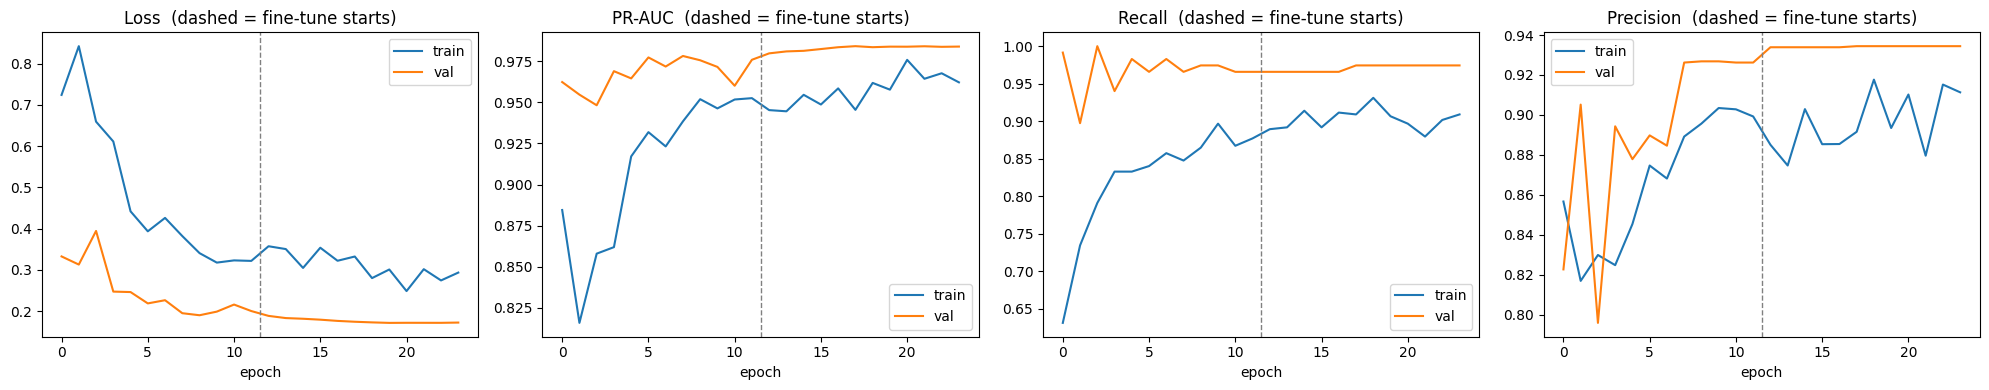

If val metrics separate from train this cleanly and this early again,
re-run the overlap check in cell 6 before trusting the result.


In [ ]:
def merge_hist(*hs):
    out = {}
    for h in hs:
        for k, v in h.history.items():
            out.setdefault(k, []).extend(v)
    return out

H      = merge_hist(hist_head, hist_ft)
switch = len(hist_head.history["loss"])

panels = [("loss", "val_loss", "Loss"),
          ("pr_auc", "val_pr_auc", "PR-AUC"),
          ("recall", "val_recall", "Recall"),
          ("precision", "val_precision", "Precision")]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (a, b, title) in zip(axes, panels):
    ax.plot(H[a], label="train")
    ax.plot(H[b], label="val")
    ax.axvline(switch - 0.5, ls="--", c="gray", lw=1)
    ax.set_title(f"{title}  (dashed = fine-tune starts)")
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()

print("If val metrics separate from train this cleanly and this early again,")
print("re-run the overlap check in cell 6 before trusting the result.")

## 14. Pick the decision threshold on validation

Positive class is now genuinely `cracked`, so TARGET_PRECISION constrains
*cracked* precision and we maximize *cracked* recall under it - the number that
actually matters for the product.

threshold = 0.108  ->  val precision 0.900, recall 1.000
val PR-AUC : 0.9839
val ROC-AUC: 0.9759


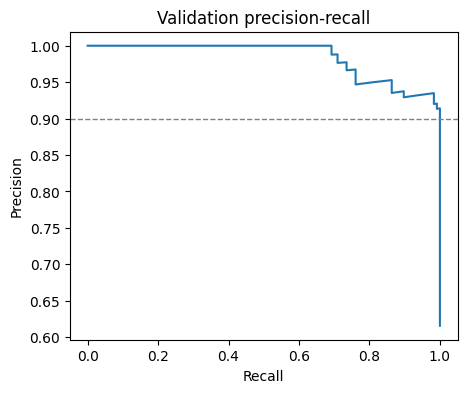

In [ ]:
def predict_probs(ds):
    y_true = np.concatenate([y for _, y in ds]).ravel()
    y_prob = model.predict(ds, verbose=0).ravel()
    return y_true, y_prob

val_y_arr, val_p = predict_probs(val_ds)
prec, rec, thr = precision_recall_curve(val_y_arr, val_p)

ok = np.where(prec[:-1] >= TARGET_PRECISION)[0]
if len(ok):
    best = ok[np.argmax(rec[:-1][ok])]
    THRESHOLD = float(thr[best])
    print(f"threshold = {THRESHOLD:.3f}  ->  val precision {prec[best]:.3f}, recall {rec[best]:.3f}")
else:
    THRESHOLD = 0.5
    print(f"no threshold reaches precision {TARGET_PRECISION}; falling back to 0.5")

print("val PR-AUC :", round(average_precision_score(val_y_arr, val_p), 4))
print("val ROC-AUC:", round(roc_auc_score(val_y_arr, val_p), 4))

plt.figure(figsize=(5, 4))
plt.plot(rec, prec)
plt.axhline(TARGET_PRECISION, ls="--", c="gray", lw=1)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Validation precision-recall")
plt.show()

## 15. Test evaluation

In [ ]:
test_y_arr, test_p = predict_probs(test_ds)
test_pred = (test_p >= THRESHOLD).astype(int)   # v3 bug: hardcoded 0.5 here but titled the plot with THRESHOLD

print("test PR-AUC :", round(average_precision_score(test_y_arr, test_p), 4))
print("test ROC-AUC:", round(roc_auc_score(test_y_arr, test_p), 4))
print("n test images:", len(test_y_arr), "(", int(test_y_arr.sum()), "cracked )")
print()
print(classification_report(test_y_arr, test_pred, target_names=LABEL_NAMES, digits=3))

cm = confusion_matrix(test_y_arr, test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion matrix @ threshold {THRESHOLD:.3f}")
plt.show()


## 16. Grad-CAM sanity check - run this before trusting any metric above

After the label flip the model's sigmoid is P(cracked), so the CAM below shows
evidence **for cracked** - relu no longer deletes the crack regions the way it
did in v3 (where the score was P(not_cracked) and cracked-image heatmaps were
meaningless).

In [ ]:
def grad_cam(img):
    x = tf.expand_dims(img, 0)
    with tf.GradientTape() as tape:
        feats = base_model(x, training=False)
        tape.watch(feats)
        score = head_model(feats, training=False)[:, 0]   # = P(cracked) after label flip
    grads   = tape.gradient(score, feats)
    weights = tf.reduce_mean(tf.cast(grads, tf.float32), axis=(1, 2))
    feats   = tf.cast(feats, tf.float32)
    cam     = tf.reduce_sum(feats * weights[:, None, None, :], axis=-1)[0]
    cam     = tf.nn.relu(cam)
    cam     = cam / (tf.reduce_max(cam) + 1e-8)
    return tf.image.resize(cam[..., None], IMG_SIZE).numpy().squeeze()

# Sample from the cracked test images - we need to see how it handles known cracks.
cracked_dir = os.path.join(SPLIT_DIR, "test", "cracked")
sample_files = sorted(os.listdir(cracked_dir))[:6]

images, probs = [], []
for f in sample_files:
    img = tf.keras.utils.load_img(os.path.join(cracked_dir, f), target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    images.append(arr)
    probs.append(float(model.predict(arr[None, ...], verbose=0)[0, 0]))

fig, axes = plt.subplots(2, len(images), figsize=(20, 7))
for j, (img, p) in enumerate(zip(images, probs)):
    axes[0, j].imshow(img.astype("uint8"))
    axes[0, j].set_title(f"p_cracked={p:.2f} (true: cracked)")
    axes[0, j].axis("off")
    axes[1, j].imshow(img.astype("uint8"))
    axes[1, j].imshow(grad_cam(img), cmap="jet", alpha=0.45)
    axes[1, j].axis("off")
plt.tight_layout()
plt.show()


## 17. Save

In [ ]:
OUT_MODEL = "/content/crack_detector_convnext_tiny.keras"
OUT_META  = "/content/crack_detector_meta.json"

model.save(OUT_MODEL)

meta = {
    "backbone": "ConvNeXtTiny",
    "img_size": list(IMG_SIZE),
    "positive_class": "cracked",          # sigmoid output = P(cracked)
    "label_names": LABEL_NAMES,           # index = label
    "threshold": float(THRESHOLD),        # validation-selected, precision-constrained
    "target_precision": TARGET_PRECISION,
    "notes": "labels remapped at load time (folder order gives cracked=0; pipeline flips to cracked=1)",
}
with open(OUT_META, "w") as f:
    json.dump(meta, f, indent=2)
print("saved:", OUT_MODEL)
print("meta :", json.dumps(meta, indent=2))
